# threshold seeking

In [ ]:
# succesful experment, chacked what is the presentage of risky which gives best results (for a linear binary classifier which is trashhold on the presentage of risky messages)
import pandas as pd

In [ ]:
messages_df = pd.read_csv('trainDatasets/combined_riskfree_riskfull_messages_syntatic_fixed.csv', low_memory=False)
conversation_info_df = pd.read_csv('trainDatasets/conv_info.csv', low_memory=False)
messages_df

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

# 1. Group messages by engagement_id and compute percent of label==1
message_stats = (
    messages_df
    .groupby('engagement_id')['label']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'num_positives', 'count': 'total_messages'})
    .reset_index()
)

# Compute percentage of positive messages
message_stats['positive_percentage'] = 100 * message_stats['num_positives'] / message_stats['total_messages']

# 2. Merge with conversation info to get the true labels
merged_df = pd.merge(message_stats, conversation_info_df, on='engagement_id')

# 3. Run threshold sweep from 1% to 30%
results = []

for n in range(0,31):  # thresholds 1 to 30
    threshold = n
    
    # Predicted: conversation is positive if percentage > threshold
    merged_df['predicted_label'] = (merged_df['positive_percentage'] > threshold).astype(int)
    
    # True labels
    y_true = merged_df['gsr']
    y_pred = merged_df['predicted_label']
    
    # Compute metrics
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display or plot
print(results_df)

    threshold  precision    recall  f1_score
0           0   0.580628  0.970400  0.726539
1           1   0.582867  0.969669  0.728083
2           2   0.596158  0.964005  0.736717
3           3   0.613917  0.952677  0.746670
4           4   0.635798  0.933309  0.756349
5           5   0.654977  0.907729  0.760913
6           6   0.674052  0.883793  0.764804
7           7   0.686882  0.850539  0.760000
8           8   0.701507  0.808149  0.751061
9           9   0.710885  0.780376  0.744012
10         10   0.723481  0.735246  0.729316
11         11   0.729542  0.710214  0.719748
12         12   0.743689  0.667458  0.703515
13         13   0.749026  0.632012  0.685561
14         14   0.753475  0.594190  0.664419
15         15   0.754523  0.548694  0.635354
16         16   0.757519  0.515439  0.613461
17         17   0.765598  0.479810  0.589914
18         18   0.764669  0.447652  0.564711
19         19   0.767911  0.417139  0.540611
20         20   0.778329  0.372739  0.504077
21        

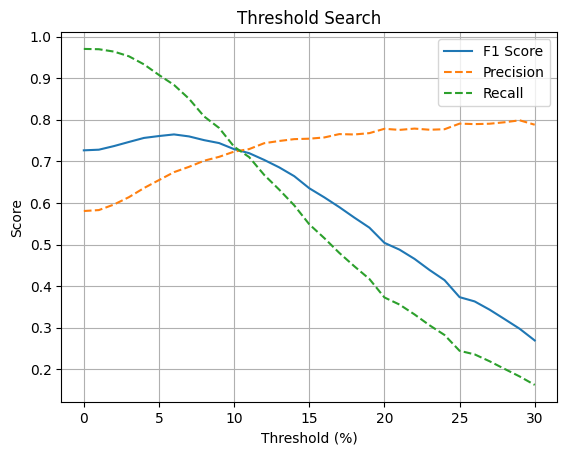

In [17]:
import matplotlib.pyplot as plt

plt.plot(results_df['threshold'], results_df['f1_score'], label='F1 Score')
plt.plot(results_df['threshold'], results_df['precision'], label='Precision', linestyle='--')
plt.plot(results_df['threshold'], results_df['recall'], label='Recall', linestyle='--')
plt.xlabel('Threshold (%)')
plt.ylabel('Score')
plt.title('Threshold Search')
plt.legend()
plt.grid(True)
plt.show()